# K-NN

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
data=pd.read_csv("Social_Network_Ads.csv")
x=data.iloc[:,:-1].values
y=data.iloc[:,-1].values
x,y

(array([[    19,  19000],
        [    35,  20000],
        [    26,  43000],
        [    27,  57000],
        [    19,  76000],
        [    27,  58000],
        [    27,  84000],
        [    32, 150000],
        [    25,  33000],
        [    35,  65000],
        [    26,  80000],
        [    26,  52000],
        [    20,  86000],
        [    32,  18000],
        [    18,  82000],
        [    29,  80000],
        [    47,  25000],
        [    45,  26000],
        [    46,  28000],
        [    48,  29000],
        [    45,  22000],
        [    47,  49000],
        [    48,  41000],
        [    45,  22000],
        [    46,  23000],
        [    47,  20000],
        [    49,  28000],
        [    47,  30000],
        [    29,  43000],
        [    31,  18000],
        [    31,  74000],
        [    27, 137000],
        [    21,  16000],
        [    28,  44000],
        [    27,  90000],
        [    35,  27000],
        [    33,  28000],
        [    30,  49000],
        [   

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
x_train,x_test,y_train,y_test

(array([[    58, 144000],
        [    59,  83000],
        [    24,  55000],
        [    26,  35000],
        [    58,  38000],
        [    42,  80000],
        [    40,  75000],
        [    59, 130000],
        [    46,  41000],
        [    41,  60000],
        [    42,  64000],
        [    37, 146000],
        [    23,  48000],
        [    25,  33000],
        [    24,  84000],
        [    27,  96000],
        [    23,  63000],
        [    48,  33000],
        [    48,  90000],
        [    42, 104000],
        [    44,  39000],
        [    32, 120000],
        [    38,  50000],
        [    32, 135000],
        [    52,  21000],
        [    53, 104000],
        [    39,  42000],
        [    38,  61000],
        [    36,  50000],
        [    36,  63000],
        [    35,  25000],
        [    35,  50000],
        [    42,  73000],
        [    47,  49000],
        [    59,  29000],
        [    49,  65000],
        [    45, 131000],
        [    31,  89000],
        [   

In [4]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
x_train,x_test

(array([[ 1.92295008e+00,  2.14601566e+00],
        [ 2.02016082e+00,  3.78719297e-01],
        [-1.38221530e+00, -4.32498705e-01],
        [-1.18779381e+00, -1.01194013e+00],
        [ 1.92295008e+00, -9.25023920e-01],
        [ 3.67578135e-01,  2.91803083e-01],
        [ 1.73156642e-01,  1.46942725e-01],
        [ 2.02016082e+00,  1.74040666e+00],
        [ 7.56421121e-01, -8.38107706e-01],
        [ 2.70367388e-01, -2.87638347e-01],
        [ 3.67578135e-01, -1.71750061e-01],
        [-1.18475597e-01,  2.20395980e+00],
        [-1.47942605e+00, -6.35303205e-01],
        [-1.28500455e+00, -1.06988428e+00],
        [-1.38221530e+00,  4.07691369e-01],
        [-1.09058306e+00,  7.55356227e-01],
        [-1.47942605e+00, -2.00722133e-01],
        [ 9.50842613e-01, -1.06988428e+00],
        [ 9.50842613e-01,  5.81523798e-01],
        [ 3.67578135e-01,  9.87132798e-01],
        [ 5.61999628e-01, -8.96051849e-01],
        [-6.04529329e-01,  1.45068594e+00],
        [-2.12648508e-02, -5.773

In [5]:
from sklearn.neighbors import KNeighborsClassifier
classifier=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)


In [6]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(accuracy_score(y_test,y_pred))

[[55  3]
 [ 1 21]]
0.95


C:\Users\adity\AppData\Local\Temp\ipykernel_29096\3838288497.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


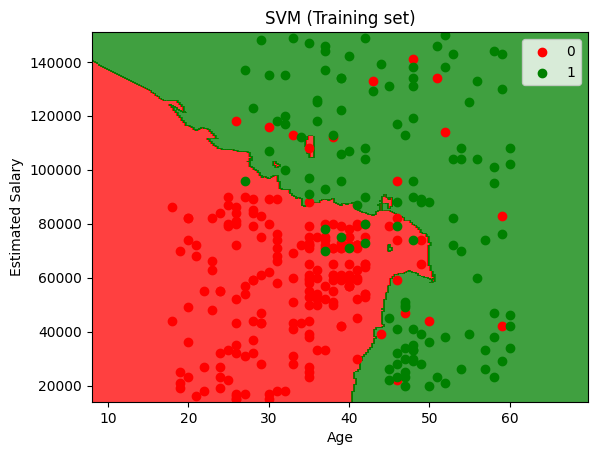

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(x_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()